<a href="https://colab.research.google.com/github/kielbas1729/customer-segmentation-ml/blob/main/Basics_of_Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automobile Customer Segmentation Classification

The goal of this project is to build machine learning models for classification of automobile customers into 4 groups A,B,C,D (previously established by the company) and compare the results to find which model performs the best.

The data set is available on Kaggle:
https://www.kaggle.com/datasets/kaushiksuresh147/customer-segmentation/data

Importing python repositories and loading database from Google Drive

In [ ]:
!pip install scikit-learn==1.2.2 # for XGBoost to work properly

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/CustomerClassificationDatabase.csv'
df = pd.read_csv(file_path)

# Initial data examination and preprocessing

In [ ]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10695 non-null  int64  
 1   Gender           10695 non-null  object 
 2   Ever_Married     10505 non-null  object 
 3   Age              10695 non-null  int64  
 4   Graduated        10593 non-null  object 
 5   Profession       10533 non-null  object 
 6   Work_Experience  9597 non-null   float64
 7   Spending_Score   10695 non-null  object 
 8   Family_Size      10247 non-null  float64
 9   Var_1            10587 non-null  object 
 10  Segmentation     10695 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 919.2+ KB


In [ ]:
df.duplicated().sum()

38

In [ ]:
df.drop_duplicates()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
10690,467954,Male,No,29,No,Healthcare,9.0,Low,4.0,Cat_6,B
10691,467958,Female,No,35,Yes,Doctor,1.0,Low,1.0,Cat_6,A
10692,467960,Female,No,53,Yes,Entertainment,NaN,Low,2.0,Cat_6,C
10693,467961,Male,Yes,47,Yes,Executive,1.0,High,5.0,Cat_4,C


In [ ]:
df = df.drop(columns=['ID'])
df = df.rename(columns={"Var_1":"Category"})

In [ ]:
px.histogram(df, x='Segmentation', color='Segmentation', width=800, height=300)

In [ ]:
px.histogram(df,x='Age',color='Age', width=800, height=300)

In [ ]:
px.histogram(df,x='Profession',color='Profession', width=800, height=400)

In [ ]:
px.histogram(df,x='Work_Experience',color='Work_Experience', width=800, height=300)

In [ ]:
px.histogram(df,x='Family_Size',color='Family_Size', width=800, height=300)

In [ ]:
px.histogram(df,x='Category',color='Category', width=800, height=300)

In [ ]:
px.histogram(df,x='Spending_Score',color='Spending_Score',width=800, height=300)

In [ ]:
px.histogram(df, x='Gender', color='Gender',width=800, height=300)

In [ ]:
px.histogram(df,x='Ever_Married',color='Ever_Married',width=800, height=300)

In [ ]:
px.histogram(df,x='Graduated',color='Graduated',width=800, height=300)


Inplacing columns with numerical data with the most frequent value.

In [ ]:
df['Age'].fillna(df['Age'].mode()[0],inplace=True)
df['Family_Size'].fillna(df['Family_Size'].mode()[0],inplace=True)
df['Work_Experience'].fillna(df['Work_Experience'].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

,0
Gender,0
Ever_Married,190
Age,0
Graduated,102
Profession,162
Work_Experience,0
Spending_Score,0
Family_Size,0
Category,108
Segmentation,0


Encoding non-numerical data




In [ ]:
categorical_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Category', 'Spending_Score']
numerical_cols = ['Age', 'Work_Experience', 'Family_Size']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(sparse_output=False, drop='first'), categorical_cols),
        ('num','passthrough', numerical_cols)
    ]
)

df_transformed = preprocessor.fit_transform(df)
encoded_df = pd.DataFrame(df_transformed, columns=preprocessor.get_feature_names_out())
#encoded_df = pd.concat([encoded_df, df['Segmentation'], df['Spending_Score']], axis=1)
#encoded_df['Spending_Score'].replace({'Low':0,'Average':1,'High':2},inplace=True)
encoded_df = pd.concat([encoded_df, df['Segmentation']], axis=1)
encoded_df["Segmentation"].replace({"A":0,"B":1,"C":2,"D":3},inplace=True)

In [ ]:
encoded_df.head()

,cat__Gender_Male,cat__Ever_Married_Yes,cat__Ever_Married_nan,cat__Graduated_Yes,cat__Graduated_nan,cat__Profession_Doctor,cat__Profession_Engineer,cat__Profession_Entertainment,cat__Profession_Executive,cat__Profession_Healthcare,...,cat__Category_Cat_5,cat__Category_Cat_6,cat__Category_Cat_7,cat__Category_nan,cat__Spending_Score_High,cat__Spending_Score_Low,num__Age,num__Work_Experience,num__Family_Size,Segmentation
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,22.0,1.0,4.0,3
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,38.0,1.0,3.0,0
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,67.0,1.0,1.0,1
3,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,67.0,0.0,2.0,1
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,40.0,1.0,6.0,0


In [ ]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cat__Gender_Male               10695 non-null  float64
 1   cat__Ever_Married_Yes          10695 non-null  float64
 2   cat__Ever_Married_nan          10695 non-null  float64
 3   cat__Graduated_Yes             10695 non-null  float64
 4   cat__Graduated_nan             10695 non-null  float64
 5   cat__Profession_Doctor         10695 non-null  float64
 6   cat__Profession_Engineer       10695 non-null  float64
 7   cat__Profession_Entertainment  10695 non-null  float64
 8   cat__Profession_Executive      10695 non-null  float64
 9   cat__Profession_Healthcare     10695 non-null  float64
 10  cat__Profession_Homemaker      10695 non-null  float64
 11  cat__Profession_Lawyer         10695 non-null  float64
 12  cat__Profession_Marketing      10695 non-null 

Splitting the data into training set and test set

In [ ]:
X=encoded_df.drop(columns=['Segmentation'])
y=encoded_df['Segmentation']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_test_scores = dict() # to keep record of the results

# Logistic Regression

Normalizing the dataset

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modelling

In [ ]:
lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=10)
y_pred_train=lr.predict(X_train_scaled)
y_pred_test=lr.predict(X_test_scaled)

Logistic Regression results

In [ ]:
print("Cross-Validation Score:", cv_scores.mean())
print("Train Set Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Set Accuracy:", accuracy_score(y_test, y_pred_test))
best_test_scores["Logistic Regression"] = accuracy_score(y_test, y_pred_test)

Cross-Validation Score: 0.46551907416516364
Train Set Accuracy: 0.47218326320710613
Test Set Accuracy: 0.47732585320243104


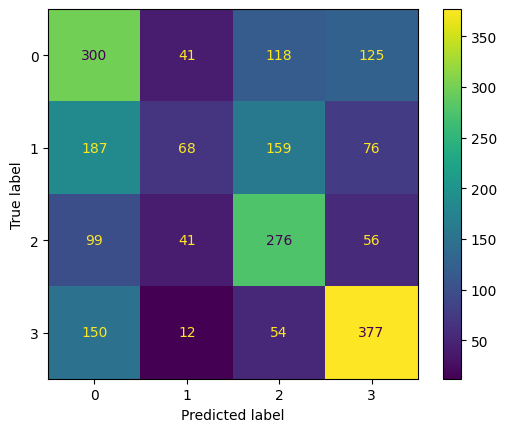

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# K-Nearest Neighbours

Hyperparameter tuning

In [ ]:
k_values = range(1, 50)
cv_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()
    cv_scores.append(cv_score)
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

In [ ]:
print("Best k value:", best_k)
print("Best Cross-Validation Score:", best_score)

Best k value: 38
Best Cross-Validation Score: 0.45137756244640237


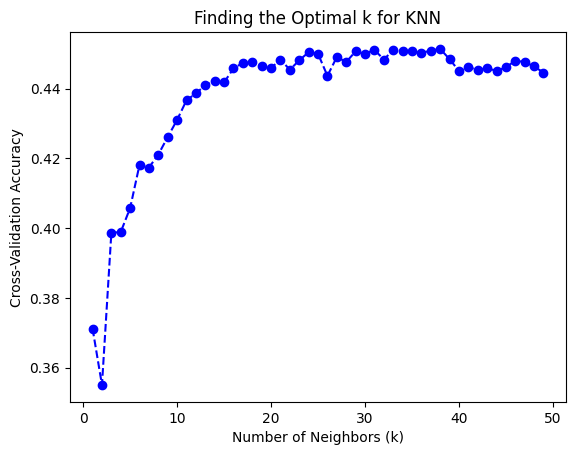

In [ ]:
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed', color='b')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Finding the Optimal k for KNN")
plt.show()

Modelling

In [ ]:
knn = KNeighborsClassifier(n_neighbors = best_k)
knn.fit(X_train_scaled, y_train)
cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=10)
y_pred_train = knn.predict(X_train_scaled)
y_pred_test = knn.predict(X_test_scaled)
best_test_scores["KNN"] = accuracy_score(y_test, y_pred_test)

KNN results

In [ ]:
print("Cross-Validation Score:",cv_scores.mean())
print("Train Set Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Set Accuracy:", accuracy_score(y_test, y_pred_test))

Cross-Validation Score: 0.45231076132699355
Train Set Accuracy: 0.4911173445535297
Test Set Accuracy: 0.4693782141187471


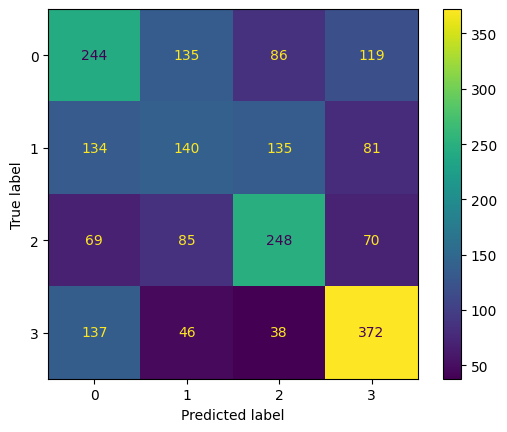

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# Decision Tree

Hyperparameter tuning

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier()

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

Best Parameters: {'criterion': 'gini', 'max_depth': 7}
Best Cross-Validation Score: 0.4650520682554335


Modelling

In [ ]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)
best_test_scores["Decision Tree"] = accuracy_score(y_test, y_pred_test)

Decision Tree results

In [ ]:
print("Cross-Validation Score:", cv_scores.mean())
print("Train Set Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Set Accuracy:", accuracy_score(y_test, y_pred_test))

Cross-Validation Score: 0.4648183551183382
Train Set Accuracy: 0.5014025245441796
Test Set Accuracy: 0.463768115942029


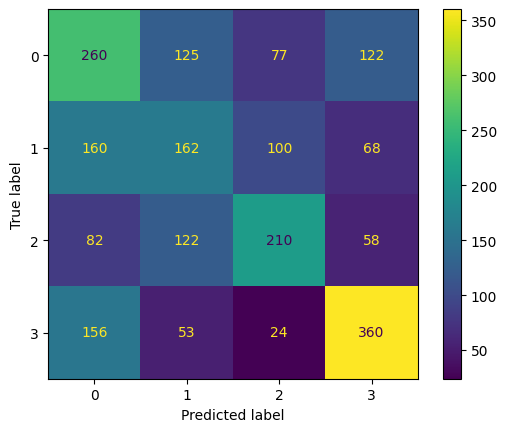

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# Random Forests

Hyperparameter tuning

In [ ]:
rf=RandomForestClassifier()

param_grid = {
    'n_estimators': [10, 25, 50, 65, 75, 85, 100],
    'max_depth': [5, 10, 15, None],
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best Cross-Validation Score: 0.47381825679905176


Modelling

In [ ]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)
best_test_scores["Random Forest"] = accuracy_score(y_test, y_pred_test)

Random Forest results

In [ ]:
print("Cross-Validation Score:", cv_scores.mean())
print("Train Set Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Set Accuracy:", accuracy_score(y_test, y_pred_test))

Cross-Validation Score: 0.471831251331407
Train Set Accuracy: 0.6009817671809257
Test Set Accuracy: 0.48153342683496964


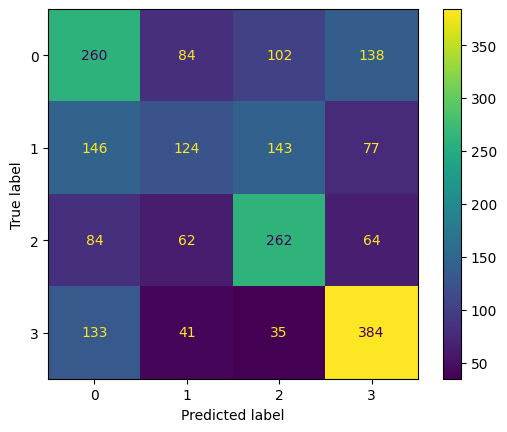

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# XGBoost

Hyperparameter tuning

In [ ]:
if xgb_tuning_completed is False:

  from xgboost import XGBClassifier
  xgb = XGBClassifier()

  param_grid = {
      'n_estimators': [50, 100, 150, 200, 250],
      'max_depth': [1, 2, 3, 4, 5],
      'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
  }

  grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, n_jobs=-1,verbose=2)
  grid_search.fit(X_train_scaled, y_train)

  best_params = grid_search.best_params_
  best_score = grid_search.best_score_
  best_model = grid_search.best_estimator_

  print("Best Parameters:", best_params)
  print("Best Cross-Validation Score:", best_score)

  xgb_tuning_completed = True

Fitting 5 folds for each of 125 candidates, totalling 625 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation Score: 0.47966231421751504


Modelling

In [ ]:
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5)
y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled)
best_test_scores["XGBoost"] = accuracy_score(y_test, y_pred_test)

XGBoost results

In [ ]:
print("Cross-Validation Score:", cv_scores.mean())
print("Train Set Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Set Accuracy:", accuracy_score(y_test, y_pred_test))
best_test_scores["XGBoost"] = accuracy_score(y_test, y_pred_test)

Cross-Validation Score: 0.47966231421751504
Train Set Accuracy: 0.5085320243104254
Test Set Accuracy: 0.48667601683029454


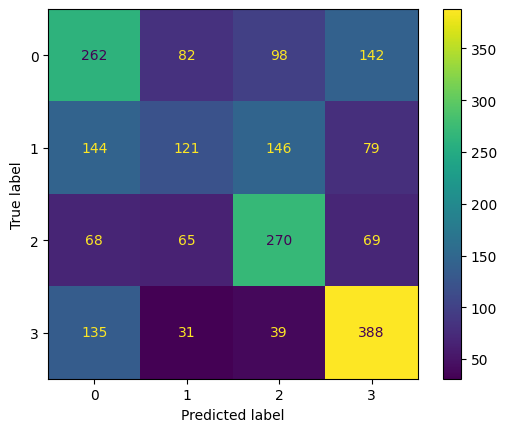

In [ ]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm).plot()
plt.show()

# Conclusions

In [ ]:
for model, score in best_test_scores.items():
    print(f"{model}: {score}")

Logistic Regression: 0.47732585320243104
KNN: 0.4693782141187471
Decision Tree: 0.463768115942029
Random Forest: 0.48153342683496964
XGBoost: 0.48667601683029454


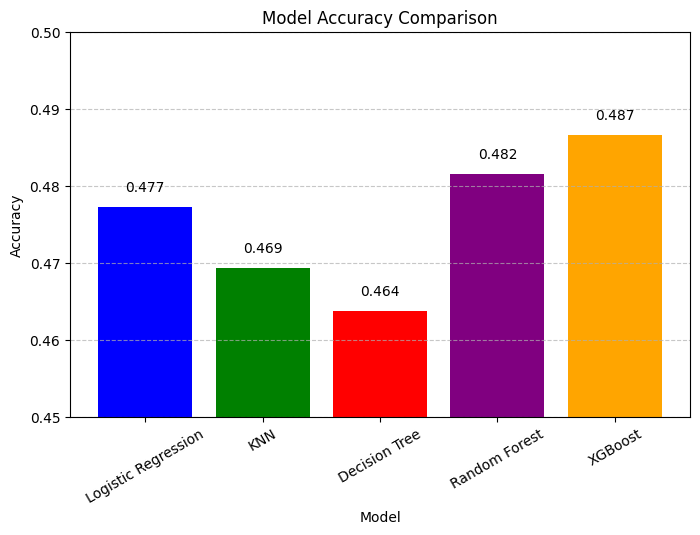

In [ ]:
results = pd.DataFrame(best_test_scores.items(), columns=["Model", "Accuracy"])

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"], color=['blue', 'green', 'red', 'purple', 'orange'])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.45, 0.50)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(results["Accuracy"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center', fontsize=10)

plt.show()

In this classification task, XGBoost model proved to be the best but also most resource-consuming. Logistic Regression model was to me surprisingly effective and I think it might provide a quick and decently good classification of new customers into four groups if the company expands rapidly on the market.

The nearly 50% accuracy the model achieved, is a decent result in my opinion. It is almost twice as good as a random guess and I suspect that there can be a lot of noise in the customer dataset, which makes it harder to classify customers accurately.